In [1]:
import cafe

cafe.logger.setLevel("DEBUG")
cafe.settings.backend = "python_function"

[07/24/2025 09:42:53] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

Data

In [ ]:
fadata = cafe.data.read_pancrease(n_obs=500)
cluster_key = "clusters"
fadata

                      DEBUG    sample random cells                                                                                                                                                      
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    FateAnnData add_trajectory                                                                                                                                               


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

                      DEBUG    FateAnnData add_trajectory                                                                                                                                               
                      DEBUG    plot_trajectory                                                                                                                                                          
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[07/24/2025 09:42:54] DEBUG    add waypoints shape is (210, 500), finished!                                                                                                                         

<Axes: title={'center': 'clusters'}, xlabel='UMAP1', ylabel='UMAP2'>

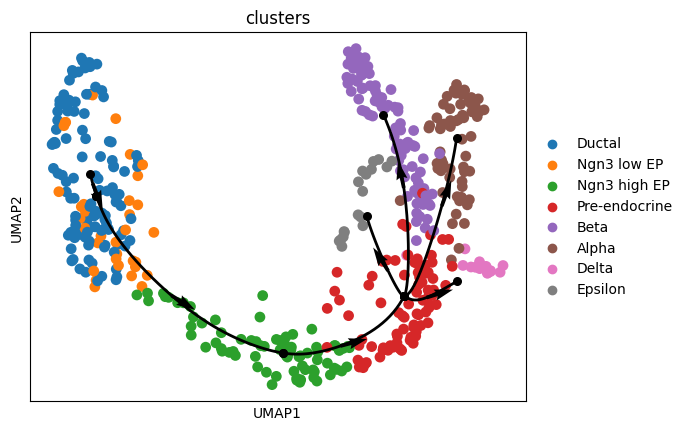

In [ ]:
import pandas as pd

# add milestone network manually
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network, cluster_key=cluster_key)
cafe.plot.plot_trajectory(fadata, color=cluster_key)

Ray tune, Method and plot

In [4]:
help(cafe.method.scvelo)

Help on FateMethod in module cafe.method.fate_method:

<cafe.method.fate_method.FateMethod object>
    _summary_
    
    Args:
        adata (ad.AnnData): AnnData object
        repreprocess (bool, optional): whether reprocess the anndata object, including feature selection, normalization, scale, pca and neighbor computation. Defaults to True.
        filter_and_normalize_kwargs (dict, optional): Parameters for preprocess in scvelo style, refer to "scvelo.pp.filter_and_normalize"(https://scvelo.readthedocs.io/en/stable/scvelo.pp.filter_and_normalize.html). Defaults to {}.
        moments_kwargs (dict, optional): Parameters for neighbor moment in scvelo style, refer to "scvelo.pp.moments"(https://scvelo.readthedocs.io/en/stable/scvelo.pp.moments.html). Defaults to {}.
        velocity_kwargs (dict, optional): refer to https://scvelo.readthedocs.io/en/stable/scvelo.tl.velocity.html. Defaults to {}.
        velocity_graph_kwargs (dict, optional): refer to https://scvelo.readthedocs.io/en

In [5]:
import os
from ray import tune

save_dir = f"{os.getcwd()}/img/25.07.24-raytune_scvelo"
# base common parameter
base_parameters = {
}

# search space, grid search
search_space = {
    "filter_and_normalize_kwargs": tune.grid_search([
        {"n_top_genes": 1000},
        {"n_top_genes": 2000},
        {"n_top_genes": 3000},
    ]),
    "moments_kwargs": tune.grid_search([
        {"n_neighbors": 10},
        {"n_neighbors": 20},
        {"n_neighbors": 30},
    ]),
    # more parameters
}


def objective(config):
    # extract parameter
    parameters = {**config, **base_parameters}

    # execute method
    id = str(config)
    cafe.method.scvelo(fadata, **parameters, backend_name="python_function", id=id)

    # plot
    save = f"{save_dir}/{id}.jpg"
    cafe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key, save=save)

    # calc metric
    metric_dict = cafe.metric.calculate_metrics(fadata, now_model=id, ref_model="ref", simplify=False, metrics=["him", "correlation"])

    return metric_dict


# Raytune
tuner = tune.Tuner(objective, param_space=search_space)
results = tuner.fit()
print(results.get_best_result(metric="correlation", mode="max").config)

(raylet) Warning: The actor ImplicitFunc is very large (47 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(pid=2999172) [07/24/2025 09:43:01] INFO                                                                                                                                                                              
(pid=2999172)                                   _____     _ _ ______    _       ______            _                                                                                                                   
(pid=2999172)                                  / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
(pid=2999172)                                 | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __            

In [ ]:
# raytune is deep copy and  for every parameter combination, so it's not recorded on fadata object.
model_name_list = fadata.get_all_model_name(parse=False)
model_name_list

['ref']